## Exercise Classification

 - Import aps_failure_training_set.csv file and aps_failure_test_set.csv

 - Using training dataset, train a NN to predict the class. It indicates if there is failure in the trucks.

 - When using common accuracy metrics we know if our model is good, but is it good enough? We will define a new specific metric for this problem: **Total cost**. For each truck we say it fails, the company sends a mechanic to review the truck, which supposes a cost of 10. On the other hand, if we say there is not failure when they actually are, the truck breakdowns, which supposes a cost of 500. In summary, False positives cost 10, and False negatives cost 500.

 - Train several NN and keep the one with less total costs. Your goal is to achieve a Total cost lower than 1

 - The evaluation phase (Total cost calculation) must be done using the test dataset (aps_failure_test_set.csv)

 - Below some pieces of code that can help you complete the exercise, specially the last one, where the definition of the Total cost is

In [20]:
!pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 9.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 31.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 32.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 38.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.8 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 12.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.4/671.4 kB 31.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 22.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.

In [53]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
# !pip install sklearn
from tabulate import tabulate
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix # for model evaluation metrics
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2, l1

In [165]:
import pandas as pd

In [161]:
failure = pd.read_csv('../../Data/Deep Learning/aps_failure_training_set.csv', delimiter=',')
failure.head(3)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0


In [167]:
failure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), object(1)
memory usage: 78.3+ MB


In [163]:
failure.describe()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,...,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,...,4.454897e+05,2.111264e+05,4.457343e+05,3.939462e+05,3.330582e+05,3.462714e+05,1.387300e+05,8.388915e+03,0.090579,0.212756
std,1.454301e+05,3.478962,7.948749e+08,4.040441e+07,161.543373,209.792592,2.047846e+04,3.420053e+04,1.503220e+05,7.617312e+05,...,1.155540e+06,5.433188e+05,1.168314e+06,1.121044e+06,1.069160e+06,1.728056e+06,4.495100e+05,4.747043e+04,4.368855,8.830641
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.340000e+02,0.000000,1.600000e+01,2.400000e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.936000e+03,1.166000e+03,2.700000e+03,3.584000e+03,5.120000e+02,1.100000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.077600e+04,0.000000,1.520000e+02,1.260000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.337960e+05,1.120860e+05,2.215180e+05,1.899880e+05,9.243200e+04,4.109800e+04,3.812000e+03,0.000000e+00,0.000000,0.000000
75%,4.866800e+04,0.000000,9.640000e+02,4.300000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.383960e+05,2.182320e+05,4.666140e+05,4.032220e+05,2.750940e+05,1.678140e+05,1.397240e+05,2.028000e+03,0.000000,0.000000
max,2.746564e+06,204.000000,2.130707e+09,8.584298e+09,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,7.793393e+07,3.775839e+07,9.715238e+07,5.743524e+07,3.160781e+07,1.195801e+08,1.926740e+07,3.810078e+06,482.000000,1146.000000


In [ ]:
import plotly
import plotly.graph_objs as go

In [ ]:
# Código para pintar gráfico con el porcentaje de valores perdidos por variable
NULL_RATIO_TRHESHOLD = 0 # Set the null ratio threshold required


null_ratios = (data.isnull().sum() / data.shape[0])
null_ratios_over_threshold = null_ratios[null_ratios > NULL_RATIO_TRHESHOLD].sort_values(ascending=False)

data_go = [
    go.Bar(
        x=null_ratios_over_threshold.index,
        y=null_ratios_over_threshold
    )
]

fig = go.Figure(data=data_go, layout={
    "title": "Null Ratio for Features with Null Ratio Exceeding {}".format(NULL_RATIO_TRHESHOLD)
})

plotly.offline.iplot(fig)

In [ ]:
null_ratios_over_threshold = null_ratios[null_ratios > NULL_RATIO_TRHESHOLD].sort_values(ascending=False)
nan_columns = list(null_ratios_over_threshold[null_ratios_over_threshold>0.1].index)

In [ ]:
# eliminamos las variables con demaisados missing, y corregimos por la media los que solo tienen hasta un 10% de valores perdidos
data_val.drop(nan_columns, axis = 1, inplace = True)
for d in data_val.columns:
  data_val[d] = data_val[d].fillna(data_val[d].mean())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,0:-1],
                                                    data.iloc[:,-1].astype(int), train_size = 0.8, random_state = 0)
X_train.head(3)

In [ ]:
# Para equilibrar la variable respuesta
ros = RandomOverSampler(random_state=42)
X_train, y_train= ros.fit_resample(X_train, y_train)

In [ ]:
scaler = StandardScaler()
sc = scaler.fit(X_train)

train_sc = sc.transform(X_train)
X_train_sc = pd.DataFrame(train_sc)
X_train_sc.columns = X_train.columns

test_sc = sc.transform(X_test)
X_test_sc = pd.DataFrame(test_sc)
X_test_sc.columns = X_test.columns

print(X_train_sc.shape)
print(X_test_sc.shape)

In [ ]:
# Escalamos los datos de validación con los parámetros de los del conjunto de entrenamiento
val_sc = sc.transform(X_val)
X_val_sc = pd.DataFrame(val_sc)
X_val_sc.columns = X_val.columns

In [ ]:
X_val = data_val.iloc[:,0:-1]
y_val = data_val.iloc[:,-1]

In [ ]:
# código para representar la matriz de confusión a partir de la predicción de la red entrenada
# En la última línea tenemos cómo calcular el Total Cost
predictions = MLP_Clas.predict(X_test_sc, verbose = 0).round(0)
conf_mat = confusion_matrix(y_test, predictions)
print(tabulate(conf_mat,headers = ['pred breackdown No','pred breackdown Yes'], showindex = ['real breackdown No','real breackdown Yes'],
               tablefmt = 'fancy_grid'))

print(classification_report(y_test, predictions))

print("Total cost: {}".format((conf_mat[1][0] * 500 + conf_mat[0][1] * 10) / X_test_sc.shape[0]))

## Exercise Regression

 - Import medical_score_train.csv and medical_score_test.csv

 - Using training dataset, train a NN for medical score prediction

 - Your goal is to achieve a MAE lower than 8

In [4]:
import pandas as pd

In [12]:
medical = pd.read_csv('../../Data/Deep Learning/medical_score_train.csv', delimiter=';')
medical.head(3)

,Id,score,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29
0,403,34.130,0.00243,0.000018,0.00108,0.00124,0.00323,0.01147,0.105,0.00625,...,-0.824511,-1.217875,-0.432389,-1.455320,-0.280675,0.681113,0.375320,0.764563,-0.237859,-0.282198
1,1477,19.000,0.00280,0.000021,0.00087,0.00128,0.00260,0.01575,0.137,0.00812,...,0.080466,-0.812559,1.512731,0.070331,2.368754,-0.256309,1.315997,0.093631,-0.389538,1.396095
2,5342,43.104,0.00412,0.000028,0.00162,0.00213,0.00487,0.02644,0.242,0.01150,...,-0.060555,-0.027766,-0.123652,0.820478,1.054439,1.922146,-1.262435,2.017997,0.687229,-0.935456


In [16]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      4141 non-null   int64  
 1   score   4141 non-null   float64
 2   V3      4141 non-null   float64
 3   V4      4141 non-null   float64
 4   V5      4141 non-null   float64
 5   V6      4141 non-null   float64
 6   V7      4141 non-null   float64
 7   V8      4141 non-null   float64
 8   V9      4141 non-null   float64
 9   V10     4141 non-null   float64
 10  V11     4141 non-null   float64
 11  V12     4141 non-null   float64
 12  V13     4141 non-null   float64
 13  V14     4141 non-null   float64
 14  V15     4141 non-null   float64
 15  V16     4141 non-null   float64
 16  V17     4141 non-null   float64
 17  V18     4141 non-null   float64
 18  V19     4141 non-null   float64
 19  V20     4141 non-null   float64
 20  V21     4141 non-null   float64
 21  V22     4141 non-null   float64
 22  

In [18]:
medical.describe()

,Id,score,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29
count,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,...,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000,4141.000000
mean,2940.652499,29.121340,0.006104,0.000044,0.002964,0.003245,0.008893,0.034051,0.311054,0.017160,...,-0.012633,-0.025192,-0.000963,0.014772,0.008972,-0.007462,-0.016772,-0.000486,-0.005106,-0.018972
std,1699.192364,10.755535,0.005490,0.000035,0.003076,0.003616,0.009229,0.025476,0.227168,0.013016,...,1.001635,1.000682,1.008123,0.989822,0.996655,0.988960,1.026635,1.000286,0.990513,1.003466
min,1.000000,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,0.003060,0.026000,0.001610,...,-3.380800,-3.478111,-3.477503,-3.640632,-4.101566,-3.325202,-4.181709,-3.271369,-3.914810,-3.940039
25%,1475.000000,21.371000,0.003600,0.000023,0.001590,0.001830,0.004780,0.019260,0.177000,0.009310,...,-0.686830,-0.710558,-0.684078,-0.653262,-0.667845,-0.677333,-0.710010,-0.684800,-0.667929,-0.719007
50%,2946.000000,27.630000,0.004900,0.000035,0.002250,0.002480,0.006760,0.027750,0.255000,0.013770,...,-0.016551,-0.041247,0.010535,0.019838,0.012707,-0.014778,-0.022363,-0.017580,-0.020160,-0.018618
75%,4415.000000,36.483000,0.006770,0.000053,0.003270,0.003430,0.009800,0.039990,0.366000,0.020690,...,0.656291,0.660537,0.662715,0.676001,0.678279,0.649582,0.657142,0.643342,0.641950,0.659158
max,5873.000000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,0.239150,1.970000,0.162670,...,3.521048,4.089038,3.415772,3.771027,3.904879,3.628111,4.551681,3.833876,3.459594,3.540049


In [71]:
medical_1=medical.copy()

In [73]:
medical_1=medical_1.drop(columns=["Id","score"])

In [87]:
X_train, X_test, y_train, y_test = train_test_split(medical_1, 
                                                    medical['score'], test_size=0.2, random_state=0)

In [89]:
X_train.head()

,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29
50,0.00354,0.000019,0.00173,0.00201,0.00519,0.01695,0.159,0.00870,0.00984,0.01298,...,-0.342525,0.131178,0.441993,0.705513,-0.585027,-0.451195,0.333431,1.311031,-0.946694,-1.250781
64,0.00523,0.000038,0.00283,0.00264,0.00849,0.02347,0.218,0.00985,0.00950,0.01044,...,-0.336604,-0.812599,-0.332020,0.803171,-0.437687,-0.723893,-1.030945,-1.131642,0.225541,-0.777905
1523,0.00363,0.000024,0.00129,0.00140,0.00387,0.02675,0.225,0.01269,0.01653,0.02105,...,-0.528140,1.351238,-1.205589,-0.789281,0.709038,0.798746,-0.291179,0.370667,2.485730,-0.947459
1101,0.00358,0.000028,0.00165,0.00197,0.00496,0.02089,0.181,0.01156,0.01337,0.01707,...,-0.520436,-0.750829,-1.300435,0.627354,-0.657678,0.235976,-1.913730,-0.003854,0.902565,-0.364241
3449,0.00417,0.000022,0.00239,0.00231,0.00718,0.02303,0.208,0.01070,0.01281,0.02144,...,0.547487,0.538761,1.306252,-0.412920,1.625565,-0.888455,0.155212,-0.060092,0.924102,0.150212


In [91]:
y_train.head()

50      24.787
64      41.241
1523    17.800
1101    20.185
3449    38.814
Name: score, dtype: float64

In [93]:
from sklearn.preprocessing import StandardScaler

# 1) Identify numeric columns
num_cols = X_train.select_dtypes(include=["number"]).columns

# 2) Fit scaler on train
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

# 3) Transform train → create a new DataFrame with “_st” column names
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train[num_cols]),
    columns=[f"{c}_st" for c in num_cols],
    index=X_train.index
)

# 4) Similarly for test
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=[f"{c}_st" for c in num_cols],
    index=X_test.index
)

# 5) Concatenate back to your original X_train / X_test
X_train = pd.concat([X_train, X_train_scaled], axis=1)
X_test  = pd.concat([X_test,  X_test_scaled ], axis=1)

In [99]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3312 entries, 50 to 2732
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V3      3312 non-null   float64
 1   V4      3312 non-null   float64
 2   V5      3312 non-null   float64
 3   V6      3312 non-null   float64
 4   V7      3312 non-null   float64
 5   V8      3312 non-null   float64
 6   V9      3312 non-null   float64
 7   V10     3312 non-null   float64
 8   V11     3312 non-null   float64
 9   V12     3312 non-null   float64
 10  V13     3312 non-null   float64
 11  V14     3312 non-null   float64
 12  V15     3312 non-null   float64
 13  V16     3312 non-null   float64
 14  V17     3312 non-null   float64
 15  V18     3312 non-null   float64
 16  V19     3312 non-null   float64
 17  V20     3312 non-null   float64
 18  V21     3312 non-null   float64
 19  V22     3312 non-null   float64
 20  V23     3312 non-null   float64
 21  V24     3312 non-null   float64
 22  V25 

In [123]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 829 entries, 3839 to 177
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V3      829 non-null    float64
 1   V4      829 non-null    float64
 2   V5      829 non-null    float64
 3   V6      829 non-null    float64
 4   V7      829 non-null    float64
 5   V8      829 non-null    float64
 6   V9      829 non-null    float64
 7   V10     829 non-null    float64
 8   V11     829 non-null    float64
 9   V12     829 non-null    float64
 10  V13     829 non-null    float64
 11  V14     829 non-null    float64
 12  V15     829 non-null    float64
 13  V16     829 non-null    float64
 14  V17     829 non-null    float64
 15  V18     829 non-null    float64
 16  V19     829 non-null    float64
 17  V20     829 non-null    float64
 18  V21     829 non-null    float64
 19  V22     829 non-null    float64
 20  V23     829 non-null    float64
 21  V24     829 non-null    float64
 22  V25 

In [127]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 3312 entries, 50 to 2732
Series name: score
Non-Null Count  Dtype  
--------------  -----  
3312 non-null   float64
dtypes: float64(1)
memory usage: 51.8 KB


In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ─── 1) Extract just the standardized columns ────────────────────────────────
# Assuming X_train, X_test are pandas DataFrames whose columns 0–25 are raw,
# columns 27–53 are the corresponding standardized versions (26 is skipped).

# 1a) If your DataFrame’s columns are integer-indexed (0,1,2,…), do:
X_train_std = X_train.iloc[:, 27:54].values   # columns 27 through 53 inclusive → 27 features
X_test_std  = X_test .iloc[:, 27:54].values

# 1b) If your DataFrame has named columns (e.g. ['V3', 'V4', …, 'V29', 'V3_st', …]),
#    but they happen to occupy positions 27–53, the same .iloc slice works.

# Verify shapes:
#   X_train_std.shape should be (n_train_samples, 27)
#   X_test_std.shape  should be (n_test_samples, 27)
print("X_train_std shape:", X_train_std.shape)
print("X_test_std  shape:", X_test_std.shape)

# ─── 2) Make sure y_train, y_test are NumPy arrays or pandas Series ──────────
# For Keras you can pass a pandas Series directly, but we’ll convert to .values here:
y_train_array = y_train.values
y_test_array  = y_test.values

# ─── 3) Rebuild your MLP with input_shape=(27,) ─────────────────────────────
MLP_Reg = Sequential()

# Change activation="ReLU" → "relu" (lowercase) and input_shape → (27,)
MLP_Reg.add(Dense(16, input_shape=(27,), activation="relu"))

MLP_Reg.add(Dense(32, activation="relu", kernel_regularizer=l2(0.001)))
MLP_Reg.add(BatchNormalization())
MLP_Reg.add(Dropout(0.2))

MLP_Reg.add(Dense(32, activation="relu", kernel_regularizer=l2(0.001)))
MLP_Reg.add(BatchNormalization())
MLP_Reg.add(Dropout(0.2))

MLP_Reg.add(Dense(1))  # single‐output regression

# ─── 4) Compile with MAE / MAPE ──────────────────────────────────────────────
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

MLP_Reg.compile(
    loss="mean_absolute_error",
    optimizer=optimizer,
    metrics=["mean_absolute_error", "mean_absolute_percentage_error"]
)

# ─── 5) Train on X_train_std / y_train_array, validate on X_test_std / y_test_array ─
history_Reg = MLP_Reg.fit(
    X_train_std,
    y_train_array,
    validation_data=(X_test_std, y_test_array),
    epochs=100,
    batch_size=16,
    verbose=2
)

# ─── 6) Evaluate on train & test ──────────────────────────────────────────────
_, mae_tr, mape_tr = MLP_Reg.evaluate(X_train_std, y_train_array, verbose=0)
_, mae_ts, mape_ts = MLP_Reg.evaluate(X_test_std,  y_test_array,  verbose=0)

print(f"MAE train: {mae_tr:.2f} ; MAPE train: {mape_tr:.2f}")
print(f"MAE test:  {mae_ts:.2f} ; MAPE test:  {mape_ts:.2f}")

X_train_std shape: (3312, 27)
X_test_std  shape: (829, 27)


/Users/javialvarez/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
207/207 - 2s - 8ms/step - loss: 13.5716 - mean_absolute_error: 13.5023 - mean_absolute_percentage_error: 50.2291 - val_loss: 8.6288 - val_mean_absolute_error: 8.5463 - val_mean_absolute_percentage_error: 35.8114
Epoch 2/100
207/207 - 0s - 1ms/step - loss: 8.7813 - mean_absolute_error: 8.6945 - mean_absolute_percentage_error: 36.8033 - val_loss: 8.4316 - val_mean_absolute_error: 8.3399 - val_mean_absolute_percentage_error: 34.9366
Epoch 3/100
207/207 - 0s - 1ms/step - loss: 8.4548 - mean_absolute_error: 8.3606 - mean_absolute_percentage_error: 35.0256 - val_loss: 8.2728 - val_mean_absolute_error: 8.1761 - val_mean_absolute_percentage_error: 34.5305
Epoch 4/100
207/207 - 0s - 1ms/step - loss: 8.4195 - mean_absolute_error: 8.3183 - mean_absolute_percentage_error: 35.0652 - val_loss: 8.2075 - val_mean_absolute_error: 8.1041 - val_mean_absolute_percentage_error: 33.9345
Epoch 5/100
207/207 - 0s - 1ms/step - loss: 8.3040 - mean_absolute_error: 8.2003 - mean_absolute_percentage_er

In [131]:
MLP_Reg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,757 (26.40 KB)

 Trainable params: 2,209 (8.63 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 4,420 (17.27 KB)

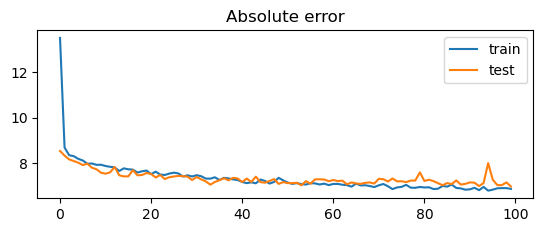

In [135]:
pyplot.subplot(211)
pyplot.title('Absolute error')
pyplot.plot(history_Reg.history['mean_absolute_error'][0:], label='train')
pyplot.plot(history_Reg.history['val_mean_absolute_error'][0:], label='test')
pyplot.legend()

In [141]:
medical_pred = MLP_Reg.predict(X_test_std, verbose=0)

In [157]:
from sklearn import metrics
import numpy as np

# 1) Compute basic error metrics
mae  = metrics.mean_absolute_error( y_test_array, medical_pred)
mse  = metrics.mean_squared_error(y_test_array, medical_pred)
rmse = np.sqrt(mse)

# 2) Compute MAPE (as a fraction; multiply by 100 if you prefer percent)
mape = metrics.mean_absolute_percentage_error(y_test_array, medical_pred)

# 3) Print them all, rounded to four decimals
print("MAE:   ", round(mae,  4))
print("MSE:   ", round(mse,  4))
print("RMSE:  ", round(rmse, 4))
print("MAPE:  ", round(mape, 4))

MAE:    6.9891
MSE:    83.8144
RMSE:   9.155
MAPE:   0.3037
